In [ ]:
from __future__ import annotations

import sys
import os

from pathlib import Path

import xarray as xr
import numpy as np

CWD = os.getcwd()
ANGSTROM_OUTPUT_DIR = Path('/Users/kris/Downloads/angstrom_fire_output/')
PATTERN = '*_*_angstrom/angstrom_fire_index.zarr'
VAR_LABEL = 'afi_init'
ENSEMBLE_DIM = 'ensemble'
TIME_DIM = 'time'
INDEX_INTERP = {'' : 4.5}

files = [f for f in ANGSTROM_OUTPUT_DIR.glob(PATTERN)]

# ds = xr.open_dataset(files[0], engine='zarr')
# da = ds[VAR_LABEL].where(ds[VAR_LABEL] <= 4.0, np.nan)
# INIT_LABEL = ds['time'][0].values

# if ENSEMBLE_DIM and TIME_DIM in ds.dims:
#     da = da.mean(dim=[ENSEMBLE_DIM, TIME_DIM])

In [93]:
ds = xr.open_dataset(files[200], engine='zarr')
da = ds[VAR_LABEL].sel(slice(2.5, 4.0))
INIT_LABEL = ds['time'][0].values

if ENSEMBLE_DIM and TIME_DIM in ds.dims:
    if len(da[ENSEMBLE_DIM]) > 1:
        print(True)
        for i in range(len(da[ENSEMBLE_DIM].values)):
            print(i)
    else:
        print('This is initialization only has one ensemble member')

ValueError: the first argument to .sel must be a dictionary

This dataset has more than 1 ensemble member


/Users/kris/miniconda3/envs/analytics/lib/python3.12/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/kris/miniconda3/envs/analytics/lib/python3.12/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/Users/kris/miniconda3/envs/analytics/lib/python3.12/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/kris/miniconda3/envs/analytics/lib/python3.12/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/Users/kris/miniconda3/envs/analytics/lib/python3.12/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/kris/miniconda3/envs/analytics/lib/python3.12/site-packages/shapely/predicates.py:878: RuntimeWarning: inv

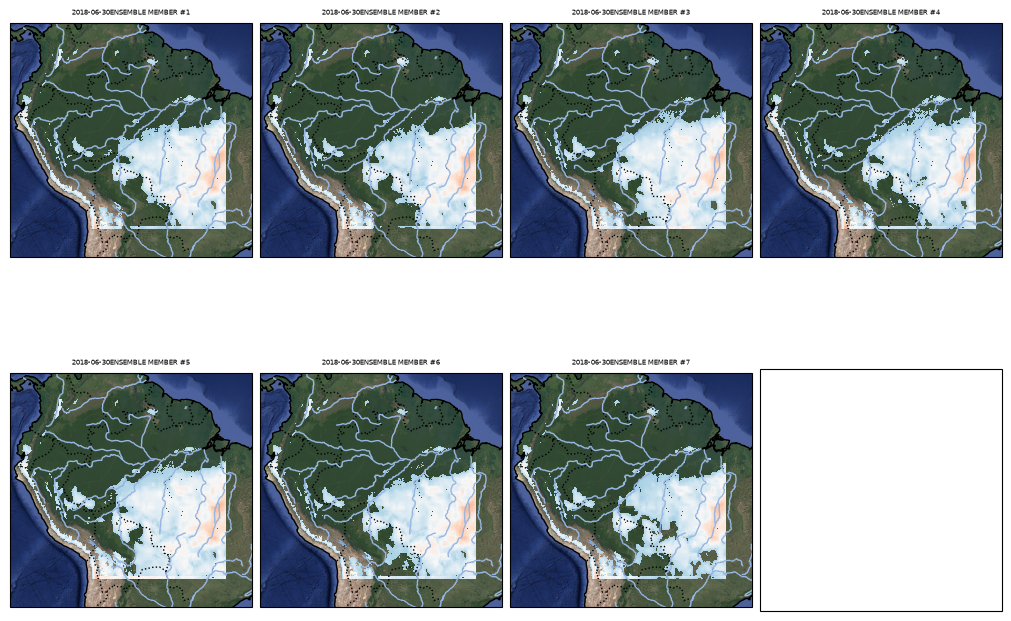

In [88]:
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from cartopy.io.img_tiles import GoogleTiles


def main(da : xr.DataArray, label : str) -> None:
    
    tiler = GoogleTiles(style='satellite')
    mercator = tiler.crs

    if ENSEMBLE_DIM and ds.sizes[ENSEMBLE_DIM] > 1:
            print(
                "This dataset has more than 1 ensemble member"
            )
            n_ens = ds.sizes[ENSEMBLE_DIM]
            fig, axes = plt.subplots(
                2, 4,
                figsize=(10,7),
                constrained_layout=True,
                subplot_kw={'projection':mercator}
            )
            axes = axes.ravel()

            for i in range(n_ens):
                ax = axes[i]
                ax.set_extent(
                    [
                        -82, -45, 
                        -25, 10
                    ], 
                    crs=ccrs.PlateCarree()
                )
                ax.add_image(tiler, 6)
                ax.add_feature(cfeature.LAND)
                ax.add_feature(cfeature.OCEAN)
                ax.add_feature(cfeature.COASTLINE)
                ax.add_feature(cfeature.BORDERS, linestyle=':')
                ax.add_feature(cfeature.LAKES, alpha=0.9)
                ax.add_feature(cfeature.RIVERS)

                da.isel({ENSEMBLE_DIM : i}).plot(ax=ax, transform=ccrs.PlateCarree(), cmap='RdBu', vmin=0, vmax=6, add_colorbar=False)
                ax.set_title(label[0:10] + f'ENSEMBLE MEMBER #{i + 1}', fontsize=5)
            
            plt.savefig(f'../../outputs/afi/images/{label[0:10]}_angstrom.png', dpi=300)
            plt.show()
            plt.close(fig)


    else:
        fig = plt.figure(figsize=(10, 7))
        ax = fig.add_subplot(1, 1, 1, projection=mercator)
        ax.set_extent(
            [
                -82, -45, 
                -25, 10
            ], 
            crs=ccrs.PlateCarree()
        )

        ax.add_image(tiler, 6)
        ax.add_feature(cfeature.LAND)
        ax.add_feature(cfeature.OCEAN)
        ax.add_feature(cfeature.COASTLINE)
        ax.add_feature(cfeature.BORDERS, linestyle=':')
        ax.add_feature(cfeature.LAKES, alpha=0.9)
        ax.add_feature(cfeature.RIVERS)

        
        #mesh = ax.pcolormesh(lon, lat, data, transform = ccrs.PlateCarree(), cmap="Reds_r", alpha=0.6)

        da.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='RdBu', vmin=0, vmax=6)
        # plt.colorbar(mesh, orientation = 'horizontal', pad=0.05, shrink = 0.7)
        plt.title(label[0:10])
        plt.savefig(f'../../outputs/afi/images/{label[0:10]}_angstrom.png')
        plt.close(fig)
        #return ax

#main(da.isel({TIME_DIM : 1}), str(INIT_LABEL))

In [ ]:
for i in range(len(files)):
    print('='*60)
    print(f'Processing : {files[i]}')
    print('='*60)
    
    ds = xr.open_dataset(files[i], engine='zarr')
    #da = ds[VAR_LABEL]
    da = ds[VAR_LABEL].where(ds[VAR_LABEL] <= 6.0, np.nan)
    INIT_DATE_ABEL = ds['time'][0].values

    # if ENSEMBLE_DIM and TIME_DIM in ds.dims:
    #     #da = da.mean(dim=[ENSEMBLE_DIM, TIME_DIM])
    #     da = da.isel({TIME_DIM : 0, ENSEMBLE_DIM : 0})

    if ENSEMBLE_DIM and TIME_DIM in ds.dims:
        #da = da.mean(dim=[ENSEMBLE_DIM, TIME_DIM])
        da = da.isel({TIME_DIM : 0})

    main(da, str(INIT_DATE_ABEL))

In [83]:
%%bash

ffmpeg -y \
    -framerate 2.5 \
    -pattern_type glob \
    -i '../../outputs/afi/images/*_angstrom*.png' \
    -c:v libx264 \
    -crf 18 \
    -pix_fmt yuv420p \
    ../../outputs/afi/output.mp4

ffmpeg version 8.0 Copyright (c) 2000-2025 the FFmpeg developers
  built with Apple clang version 16.0.0 (clang-1600.0.26.6)
  configuration: --prefix=/usr/local/Cellar/ffmpeg/8.0_1 --enable-shared --enable-pthreads --enable-version3 --cc=clang --host-cflags= --host-ldflags='-Wl,-ld_classic' --enable-ffplay --enable-gnutls --enable-gpl --enable-libaom --enable-libaribb24 --enable-libbluray --enable-libdav1d --enable-libharfbuzz --enable-libjxl --enable-libmp3lame --enable-libopus --enable-librav1e --enable-librist --enable-librubberband --enable-libsnappy --enable-libsrt --enable-libssh --enable-libsvtav1 --enable-libtesseract --enable-libtheora --enable-libvidstab --enable-libvmaf --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx264 --enable-libx265 --enable-libxml2 --enable-libxvid --enable-lzma --enable-libfontconfig --enable-libfreetype --enable-frei0r --enable-libass --enable-libopencore-amrnb --enable-libopencore-amrwb --enable-libopenjpeg --enable-libspeex --enab